
# Project Recap — Identifying Growing Industries in Canada & Regional Variation (2013–2023)
- Determine **which industries are growing in Canada** and whether there is **regional variation**.
- Use **annual data (2013–2023)** and compute a **growth metric** that reflects *real* changes, not just inflation.


In [75]:
import pandas as pd
# read data from csv
df = pd.read_csv('trade.csv')
df

,Province,industry,REF_DATE,total_trade,Value of exports,Value of imports,GDP,trade_pct_gdp
0,Alberta,0,2013,139364164.0,92750112.0,46614052.0,310713,44.853020
1,Alberta,0,2014,153658120.0,103631865.0,50026255.0,328652,46.754050
2,Alberta,0,2015,120889390.0,79154756.0,41734634.0,317182,38.113572
3,Alberta,0,2016,104104281.0,64621025.0,39483256.0,306203,33.998452
4,Alberta,0,2017,125464737.0,85402212.0,40062525.0,319212,39.304518
...,...,...,...,...,...,...,...,...
2024,Saskatchewan,91,2019,4940.0,7.0,4933.0,4812,0.102660
2025,Saskatchewan,91,2020,6097.0,7.0,6090.0,4869,0.125221
2026,Saskatchewan,91,2021,4536.0,9.0,4527.0,5004,0.090647
2027,Saskatchewan,91,2022,5862.0,51.0,5811.0,5177,0.113232


## Converted nominal GDP to **real GDP** using **CPI** from Bank of Canada.
   Formula: $$\text{Real GDP} = \frac{\text{Nominal GDP}}{\text{CPI}} \times 100 $$





In [76]:
import pandas as pd

# Load Bank of Canada CPI
cpi_m = pd.read_csv("cpi.csv")

# Keep the "Total CPI" series, parse dates, and compute annual averages
cpi_m['date'] = pd.to_datetime(cpi_m['date'])
cpi_m['year'] = cpi_m['date'].dt.year

# Identify the CPI column and rename it to 'CPI'.
cpi_cols = [c for c in cpi_m.columns if c not in ['date','year']]
cpi_m = cpi_m[['year'] + cpi_cols]
cpi_m = cpi_m.rename(columns={cpi_cols[0]:'CPI'})  # rename first numeric column to CPI

cpi_annual = cpi_m.groupby('year', as_index=False)['CPI'].mean()

# Merge with dataset (REF_DATE is the year)
df = df.merge(cpi_annual.rename(columns={'year':'REF_DATE'}), on='REF_DATE', how='left')

# Deflate to constant dollars (CPI base used by BoC series, e.g., 2002=100 or 2015=100)
df['real_gdp'] = df['GDP'] / df['CPI'] * 100
df



,Province,industry,REF_DATE,total_trade,Value of exports,Value of imports,GDP,trade_pct_gdp,CPI,real_gdp
0,Alberta,0,2013,139364164.0,92750112.0,46614052.0,310713,44.853020,122.816667,252989.279414
1,Alberta,0,2014,153658120.0,103631865.0,50026255.0,328652,46.754050,125.158333,262588.987283
2,Alberta,0,2015,120889390.0,79154756.0,41734634.0,317182,38.113572,126.566667,250604.687912
3,Alberta,0,2016,104104281.0,64621025.0,39483256.0,306203,33.998452,128.375000,238522.297955
4,Alberta,0,2017,125464737.0,85402212.0,40062525.0,319212,39.304518,130.425000,244747.556067
...,...,...,...,...,...,...,...,...,...,...
2024,Saskatchewan,91,2019,4940.0,7.0,4933.0,4812,0.102660,135.983333,3538.668955
2025,Saskatchewan,91,2020,6097.0,7.0,6090.0,4869,0.125221,136.958333,3555.095832
2026,Saskatchewan,91,2021,4536.0,9.0,4527.0,5004,0.090647,141.608333,3533.690343
2027,Saskatchewan,91,2022,5862.0,51.0,5811.0,5177,0.113232,151.241667,3422.998512


## Growth Metrics
- **CAGR (Compound Annual Growth Rate)**: 
$$
\text{CAGR} = \left( \frac{\text{real\_gdp}_{\text{end}}}{\text{real\_gdp}_{\text{start}}} \right)^{\frac{1}{n}} - 1
$$

where \( n \) = number of years (e.g., 10 for 2013–2023)


In [77]:


# ort and group

df = df.sort_values(['Province', 'industry', 'REF_DATE'])

# Helper for CAGR

import numpy as np

def cagr(start_val, end_val, years):
    if start_val is None or end_val is None:
        return np.nan
    if start_val <= 0 or end_val <= 0 or years <= 0:
        return np.nan
    return (end_val / start_val)**(1/years) - 1


In [78]:

(df[df['industry'].eq(df['industry'].unique()[0])]
   .groupby('REF_DATE', as_index=False)['real_gdp'].sum())


,REF_DATE,real_gdp
0,2013,1.487082e+06
1,2014,1.500596e+06
2,2015,1.497368e+06
3,2016,1.491836e+06
4,2017,1.513820e+06
5,2018,1.522890e+06
6,2019,1.523876e+06
7,2020,1.438816e+06
8,2021,1.474283e+06
9,2022,1.445394e+06


In [79]:

# Group by Province and industry, then compute CAGR
cagr_df = (
    df.groupby(['Province', 'industry']).apply(
        lambda g: cagr(
            g.loc[g['REF_DATE'] == 2013, 'real_gdp'].iloc[0] if (g['REF_DATE'] == 2013).any() else None,
            g.loc[g['REF_DATE'] == 2023, 'real_gdp'].iloc[0] if (g['REF_DATE'] == 2023).any() else None,
            10  # years between 2013 and 2023
        )
    ).reset_index(name='CAGR')
)

# Convert to percentage
cagr_df['CAGR_pct'] = cagr_df['CAGR'] * 100
cagr_df.sort_values('CAGR', ascending=False).head(10)

C:\Users\Sadok Jbenyeni\AppData\Local\Temp\ipykernel_25392\3629704739.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['Province', 'industry']).apply(


,Province,industry,CAGR,CAGR_pct
33,British Columbia,54,0.042965,4.296519
25,British Columbia,23,0.026972,2.697249
138,Ontario,54,0.025812,2.581207
117,Nova Scotia,54,0.022816,2.281550
159,Quebec,54,0.021829,2.182877
66,New Brunswick,22,0.021536,2.153572
30,British Columbia,51,0.020683,2.068283
149,Quebec,21,0.019995,1.999454
135,Ontario,51,0.018818,1.881793
136,Ontario,52,0.017554,1.755357


In [80]:

N = 5  # Top  5 provinces
top_per_province = (
    cagr_df.dropna(subset=['CAGR'])
           .sort_values(['Province', 'CAGR'], ascending=[True, False])
           .groupby('Province')
           .head(N)
)
top_per_province

,Province,industry,CAGR,CAGR_pct
17,Alberta,71,0.015236,1.523564
8,Alberta,48,0.006859,0.685941
2,Alberta,21,0.001594,0.159381
11,Alberta,53,0.001247,0.124719
16,Alberta,62,-0.002877,-0.287746
33,British Columbia,54,0.042965,4.296519
25,British Columbia,23,0.026972,2.697249
30,British Columbia,51,0.020683,2.068283
31,British Columbia,52,0.014055,1.405467
39,British Columbia,72,0.013223,1.322316


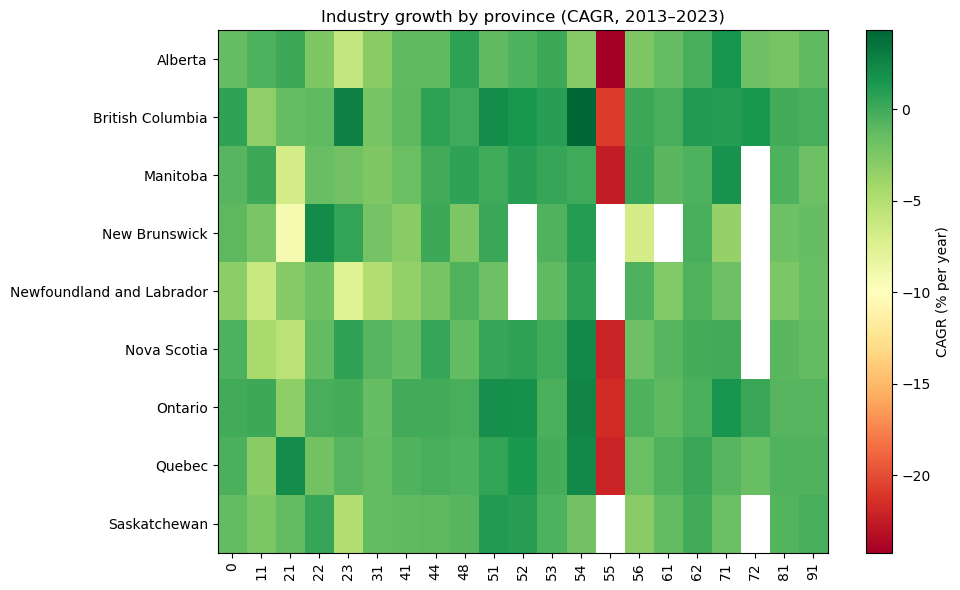

In [81]:

# Pivot for heatmap
pivot = cagr_df.pivot(index='Province', columns='industry', values='CAGR')

# Plot (sector-level labels)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.imshow(pivot.values * 100, aspect='auto', cmap='RdYlGn')
plt.colorbar(label='CAGR (% per year)')
plt.xticks(range(pivot.shape[1]), pivot.columns, rotation=90)
plt.yticks(range(pivot.shape[0]), pivot.index)
plt.title('Industry growth by province (CAGR, 2013–2023)')
plt.tight_layout()
plt.show()


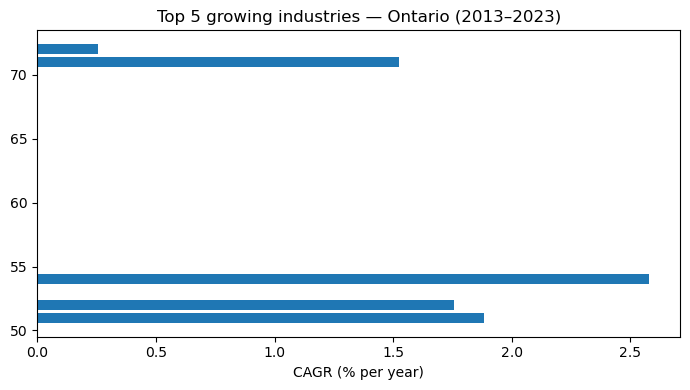

In [82]:

import matplotlib.pyplot as plt

pr = "Ontario"  # <-- change to the province you want
plotdf = (top_per_province[top_per_province['Province'] == pr]
          .sort_values('CAGR', ascending=True))
plt.figure(figsize=(7,4))
plt.barh(plotdf['industry'], plotdf['CAGR'] * 100)
plt.xlabel('CAGR (% per year)')
plt.title(f'Top {N} growing industries — {pr} (2013–2023)')
plt.tight_layout()
plt.show()